In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Bifurcations

## Saddle-node bifurcation

In [39]:
%matplotlib qt
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_min = -5
x_max = 5
x_values = np.linspace(x_min, x_max, 1000000)

r = -1
x_dot = r + x_values ** 2

arrows_positions = np.array([-3, -1, -0.5, 0, 0.5, 1, 3])
x_dot_arrows = (r + arrows_positions ** 2)
x_dot_arrows[x_dot_arrows > 1] = 1
x_dot_arrows[x_dot_arrows < -1] = -1
arrow_heights = np.zeros_like(arrows_positions)


line, = ax.plot(x_values, x_dot, lw=3, color='black')

# plot fixed points
fixed_points = np.isclose(x_dot, 0, atol=1e-5)

# determine if fixed points are stable
def get_fixed_points_and_stability(x_values, x_dot, r):
    fixed_points = np.isclose(x_dot, 0, atol=1e-5)
    x_dot_dot = r + 2 * x_values
    stable_fixed_points = x_dot_dot < 0
    unstable_fixed_points = x_dot_dot > 0
    return fixed_points, stable_fixed_points, unstable_fixed_points

fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)
stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points], 
                                         x_dot[fixed_points & stable_fixed_points],
                                         color='black', s=100, label='Fixed Points')

unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                           x_dot[fixed_points & unstable_fixed_points],
                                           color='black', s=100, label='Unstable Fixed Points',
                                           facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax_r = plt.axes([0.25, 0.2, 0.65, 0.03])
slider = Slider(ax=ax_r,
                label='r',
                valmin=-5,  # Minimum value of the slider
                valmax=5, # Maximum value of the slider
                valinit=r # Initial value of the slide
                )

def update(val):
    global stable_fixed_points_scatter, unstable_fixed_points_scatter
    new_s = val + x_values ** 2
    line.set_ydata(new_s)


    stable_fixed_points_scatter.remove()
    unstable_fixed_points_scatter.remove()

    new_fixed_points = np.isclose(new_s, 0, atol=1e-5)
    new_x_dot_dot = val + 2 * x_values
    new_stable_fixed_points = new_x_dot_dot < 0
    new_unstable_fixed_points = new_x_dot_dot > 0

    stable_fixed_points_scatter = ax.scatter(x_values[new_fixed_points & new_stable_fixed_points], 
                                             new_s[new_fixed_points & new_stable_fixed_points],
                                             color='black', s=100, label='Fixed Points')

    unstable_fixed_points_scatter = ax.scatter(x_values[new_fixed_points & new_unstable_fixed_points],
                                               new_s[new_fixed_points & new_unstable_fixed_points],
                                               color='black', s=100, label='Unstable Fixed Points',
                                               facecolors='none', edgecolors='black')


    x_dot_arrows_new = (val + arrows_positions ** 2)
    x_dot_arrows_new[x_dot_arrows_new > 1] = 1
    x_dot_arrows_new[x_dot_arrows_new < -1] = -1

    quiver.set_UVC(x_dot_arrows_new, arrow_heights)
    quiver.set_offsets(np.c_[arrows_positions, arrow_heights])
    fig.canvas.draw_idle()

ax.set_title(r'$\dot{x} = r + x^2$', fontsize=20)
slider.on_changed(update)
plt.show()

Text(0.5, 1.0, '$\\dot{x} = r + x^2$')

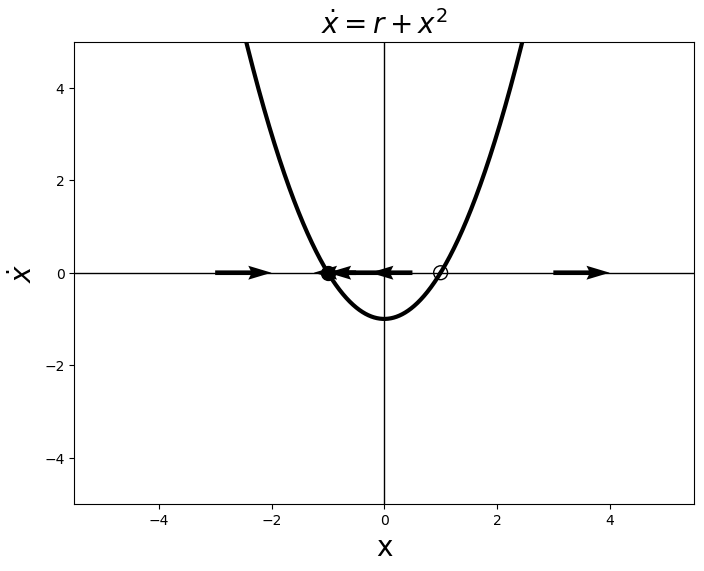

In [33]:
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

r = -1
x_dot = r + x_values ** 2

line, = ax.plot(x_values, x_dot, lw=3, color='black')

fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)
stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points], 
                                         x_dot[fixed_points & stable_fixed_points],
                                         color='black', s=100, label='Fixed Points')

unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                           x_dot[fixed_points & unstable_fixed_points],
                                           color='black', s=100, label='Unstable Fixed Points',
                                           facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax.set_title(r'$\dot{x} = r + x^2$', fontsize=20)

Text(0.5, 1.0, '$\\dot{x} = r - x^2$')

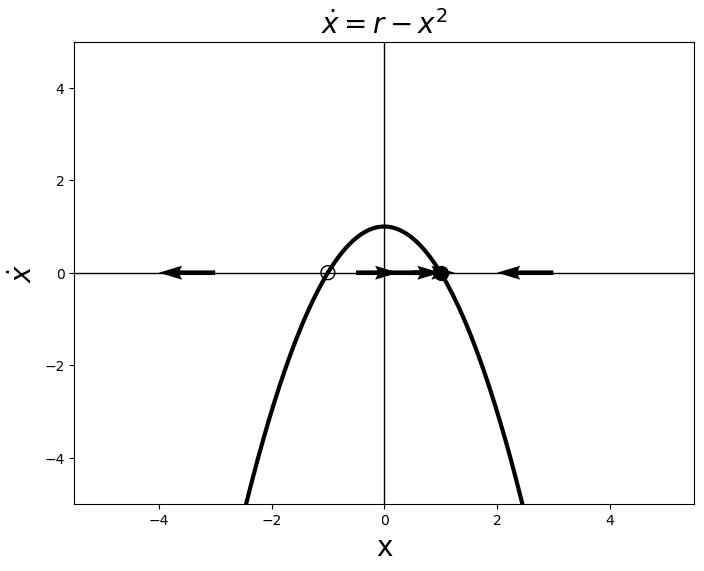

In [35]:
%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

r = 1
x_dot = r - x_values ** 2

arrows_positions = np.array([-3, -1, -0.5, 0, 0.5, 1, 3])
x_dot_arrows = (r - arrows_positions ** 2)
x_dot_arrows[x_dot_arrows > 1] = 1
x_dot_arrows[x_dot_arrows < -1] = -1
arrow_heights = np.zeros_like(arrows_positions)

line, = ax.plot(x_values, x_dot, lw=3, color='black')

def get_fixed_points_and_stability(x_values, x_dot, r):
    fixed_points = np.isclose(x_dot, 0, atol=1e-5)
    x_dot_dot = r - 2 * x_values
    stable_fixed_points = x_dot_dot < 0
    unstable_fixed_points = x_dot_dot > 0
    return fixed_points, stable_fixed_points, unstable_fixed_points

fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)
stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points], 
                                         x_dot[fixed_points & stable_fixed_points],
                                         color='black', s=100, label='Fixed Points')

unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                           x_dot[fixed_points & unstable_fixed_points],
                                           color='black', s=100, label='Unstable Fixed Points',
                                           facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax.set_title(r'$\dot{x} = r - x^2$', fontsize=20)

## Transcritical bifurcation

In [44]:
%matplotlib qt
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_min = -5
x_max = 5
x_values = np.linspace(x_min, x_max, 1000000)

r = -2
x_dot = r * x_values - x_values ** 2

arrows_positions = np.array([-3, -1, -0.5, 0, 0.5, 1, 3])
x_dot_arrows = (r * arrows_positions - arrows_positions ** 2)
x_dot_arrows[x_dot_arrows > 1] = 1
x_dot_arrows[x_dot_arrows < -1] = -1
arrow_heights = np.zeros_like(arrows_positions)

line, = ax.plot(x_values, x_dot, lw=3, color='black')

def get_fixed_points_and_stability(x_values, x_dot, r):
    fixed_points = np.isclose(x_dot, 0, atol=1e-5)
    x_dot_dot = r - 2 * x_values
    stable_fixed_points = x_dot_dot < 0
    unstable_fixed_points = x_dot_dot > 0
    return fixed_points, stable_fixed_points, unstable_fixed_points


fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)

stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points], 
                                         x_dot[fixed_points & stable_fixed_points],
                                         color='black', s=100, label='Fixed Points')

unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                           x_dot[fixed_points & unstable_fixed_points],
                                           color='black', s=100, label='Unstable Fixed Points',
                                           facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax_r = plt.axes([0.25, 0.1, 0.65, 0.03])
slider = Slider(ax=ax_r,
                label='r',
                valmin=-5,  # Minimum value of the slider
                valmax=5, # Maximum value of the slider
                valinit=r # Initial value of the slide
                )

def update(val):
    global stable_fixed_points_scatter, unstable_fixed_points_scatter
    new_x_dot = val * x_values - x_values ** 2
    line.set_ydata(new_x_dot)
    fig.canvas.draw_idle()

    stable_fixed_points_scatter.remove()
    unstable_fixed_points_scatter.remove()

    fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, new_x_dot, val)
    stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points], 
                                            new_x_dot[fixed_points & stable_fixed_points],
                                            color='black', s=100, label='Fixed Points')

    unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                               new_x_dot[fixed_points & unstable_fixed_points],
                                               color='black', s=100, label='Unstable Fixed Points',
                                               facecolors='none', edgecolors='black')

    new_x_dot_arrows = (val * arrows_positions - arrows_positions ** 2)
    new_x_dot_arrows[new_x_dot_arrows > 1] = 1
    new_x_dot_arrows[new_x_dot_arrows < -1] = -1

    quiver.set_UVC(new_x_dot_arrows, arrow_heights)
    quiver.set_offsets(np.c_[arrows_positions, arrow_heights])

ax.set_title(r'$\dot{x} = rx - x^2$', fontsize=20)
slider.on_changed(update)
plt.show()

## Supercritical pitchfork bifurcation

In [41]:
%matplotlib qt
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_min = -5
x_max = 5
x_values = np.linspace(x_min, x_max, 1000000)

r = -2
x_dot = r * x_values - x_values ** 3

arrows_positions = np.array([-3, -1, -0.5, 0, 0.5, 1, 3])
x_dot_arrows = (r * arrows_positions - arrows_positions ** 3)
x_dot_arrows[x_dot_arrows > 1] = 1
x_dot_arrows[x_dot_arrows < -1] = -1
arrow_heights = np.zeros_like(arrows_positions)

line, = ax.plot(x_values, x_dot, lw=3, color='black')

def get_fixed_points_and_stability(x_values, x_dot, r):
    fixed_points = np.isclose(x_dot, 0, atol=1e-4)
    x_dot_dot = r - 3 * x_values ** 2
    stable_fixed_points = x_dot_dot < 0
    unstable_fixed_points = x_dot_dot > 0
    return fixed_points, stable_fixed_points, unstable_fixed_points

fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)
stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points],
                                            x_dot[fixed_points & stable_fixed_points],
                                            color='black', s=100, label='Fixed Points')

unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                            x_dot[fixed_points & unstable_fixed_points],
                                            color='black', s=100, label='Unstable Fixed Points',
                                            facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax_r = plt.axes([0.25, 0.2, 0.65, 0.03])
slider = Slider(ax=ax_r,
                label='r',
                valmin=-5,  # Minimum value of the slider
                valmax=5, # Maximum value of the slider
                valinit=r # Initial value of the slide
                )

def update(val):
    global stable_fixed_points_scatter, unstable_fixed_points_scatter
    new_x_dot = val * x_values - x_values ** 3
    line.set_ydata(new_x_dot)
    fig.canvas.draw_idle()

    stable_fixed_points_scatter.remove()
    unstable_fixed_points_scatter.remove()

    fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, new_x_dot, val)
    stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points],
                                                new_x_dot[fixed_points & stable_fixed_points],
                                                color='black', s=100, label='Fixed Points')
    unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                                new_x_dot[fixed_points & unstable_fixed_points],
                                                color='black', s=100, label='Unstable Fixed Points',
                                                facecolors='none', edgecolors='black')
    
    new_x_dot_arrows = (val * arrows_positions - arrows_positions ** 3)
    new_x_dot_arrows[new_x_dot_arrows > 1] = 1
    new_x_dot_arrows[new_x_dot_arrows < -1] = -1

    quiver.set_UVC(new_x_dot_arrows, arrow_heights)
    quiver.set_offsets(np.c_[arrows_positions, arrow_heights])

ax.set_title(r'$\dot{x} = rx - x^3$', fontsize=20)
slider.on_changed(update)
plt.show()

## Subcritical pitchfork bifurcation

In [42]:
%matplotlib qt
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_min = -5
x_max = 5
x_values = np.linspace(x_min, x_max, 1000000)

r = -2
x_dot = r * x_values + x_values ** 3

arrows_positions = np.array([-3, -1, -0.5, 0, 0.5, 1, 3])
x_dot_arrows = (r * arrows_positions + arrows_positions ** 3)
x_dot_arrows[x_dot_arrows > 1] = 1
x_dot_arrows[x_dot_arrows < -1] = -1
arrow_heights = np.zeros_like(arrows_positions)

line, = ax.plot(x_values, x_dot, lw=3, color='black')

def get_fixed_points_and_stability(x_values, x_dot, r):
    fixed_points = np.isclose(x_dot, 0, atol=1e-4)
    x_dot_dot = r + 3 * x_values ** 2
    stable_fixed_points = x_dot_dot < 0
    unstable_fixed_points = x_dot_dot > 0
    return fixed_points, stable_fixed_points, unstable_fixed_points

fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)
stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points],
                                            x_dot[fixed_points & stable_fixed_points],
                                            color='black', s=100, label='Fixed Points')

unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                            x_dot[fixed_points & unstable_fixed_points],
                                            color='black', s=100, label='Unstable Fixed Points',
                                            facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax_r = plt.axes([0.2, 0.2, 0.7, 0.03])
slider = Slider(ax=ax_r,
                label='r',
                valmin=-5,  # Minimum value of the slider
                valmax=5, # Maximum value of the slider
                valinit=r # Initial value of the slide
                )

def update(val):
    global stable_fixed_points_scatter, unstable_fixed_points_scatter
    new_x_dot = val * x_values + x_values ** 3
    line.set_ydata(new_x_dot)
    fig.canvas.draw_idle()

    stable_fixed_points_scatter.remove()
    unstable_fixed_points_scatter.remove()

    fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, new_x_dot, val)
    stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points],
                                                new_x_dot[fixed_points & stable_fixed_points],
                                                color='black', s=100, label='Fixed Points')
    unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                                new_x_dot[fixed_points & unstable_fixed_points],
                                                color='black', s=100, label='Unstable Fixed Points',
                                                facecolors='none', edgecolors='black')
    
    new_x_dot_arrows = (val * arrows_positions + arrows_positions ** 3)
    new_x_dot_arrows[new_x_dot_arrows > 1] = 1
    new_x_dot_arrows[new_x_dot_arrows < -1] = -1

    quiver.set_UVC(new_x_dot_arrows, arrow_heights)
    quiver.set_offsets(np.c_[arrows_positions, arrow_heights])

ax.set_title(r'$\dot{x} = rx - x^3$', fontsize=20)
slider.on_changed(update)
plt.show()

## Imperfect bifurcation

In [43]:
%matplotlib qt
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_min = -5
x_max = 5
x_values = np.linspace(x_min, x_max, 1000000)

r = -2
h = 0
x_dot = h + r * x_values - x_values ** 3

arrows_positions = np.array([-3, -1, -0.5, 0, 0.5, 1, 3])
x_dot_arrows = (r * arrows_positions - arrows_positions ** 3)
x_dot_arrows[x_dot_arrows > 1] = 1
x_dot_arrows[x_dot_arrows < -1] = -1
arrow_heights = np.zeros_like(arrows_positions)

line, = ax.plot(x_values, x_dot, lw=3, color='black')
hline_collection = ax.hlines(-h, x_min, x_max, color='red', lw=2, linestyles='--')

def get_fixed_points_and_stability(x_values, x_dot, r):
    fixed_points = np.isclose(x_dot, 0, atol=1e-4)
    x_dot_dot = r - 3 * x_values ** 2
    stable_fixed_points = x_dot_dot < 0
    unstable_fixed_points = x_dot_dot > 0
    return fixed_points, stable_fixed_points, unstable_fixed_points

fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, x_dot, r)

stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points],
                                            x_dot[fixed_points & stable_fixed_points],
                                            color='black', s=100, label='Fixed Points')
unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],
                                            x_dot[fixed_points & unstable_fixed_points],
                                            color='black', s=100, label='Unstable Fixed Points',
                                            facecolors='none', edgecolors='black')

quiver = ax.quiver(arrows_positions, arrow_heights, x_dot_arrows, arrow_heights,
                   angles='xy', scale_units='xy', scale=1, color='black')

ax.set_ylim(-5, 5)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel(r'$\dot{x}$', fontsize=20)

# plot axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax_r = plt.axes([0.2, 0.2, 0.7, 0.03])
slider = Slider(ax=ax_r,
                label='r',
                valmin=-5,  # Minimum value of the slider
                valmax=5, # Maximum value of the slider
                valinit=r # Initial value of the slide
                )

ax_h = plt.axes([0.2, 0.15, 0.7, 0.03])
slider_h = Slider(ax=ax_h,
                 label='h',
                 valmin=-5,  # Minimum value of the slider   
                 valmax=5, # Maximum value of the slider
                 valinit=h # Initial value of the slide
                 )

def update(val):
    global stable_fixed_points_scatter, unstable_fixed_points_scatter
    new_x_dot = val * x_values - x_values ** 3
    line.set_ydata(new_x_dot)
    fig.canvas.draw_idle()

    stable_fixed_points_scatter.remove()
    unstable_fixed_points_scatter.remove()

    fixed_points, stable_fixed_points, unstable_fixed_points = get_fixed_points_and_stability(x_values, new_x_dot, val)
    stable_fixed_points_scatter = ax.scatter(x_values[fixed_points & stable_fixed_points],
                                                new_x_dot[fixed_points & stable_fixed_points],
                                                color='black', s=100, label='Fixed Points')
    unstable_fixed_points_scatter = ax.scatter(x_values[fixed_points & unstable_fixed_points],    
                                                new_x_dot[fixed_points & unstable_fixed_points],
                                                color='black', s=100, label='Unstable Fixed Points',
                                                facecolors='none', edgecolors='black')
    new_x_dot_arrows = (val * arrows_positions - arrows_positions ** 3)
    new_x_dot_arrows[new_x_dot_arrows > 1] = 1
    new_x_dot_arrows[new_x_dot_arrows < -1] = -1

    quiver.set_UVC(new_x_dot_arrows, arrow_heights)
    quiver.set_offsets(np.c_[arrows_positions, arrow_heights])

def update_h(val):
    new_h = -val
    new_segments = [[(x_min, new_h), (x_max, new_h)]]
    hline_collection.set_segments(new_segments)
    fig.canvas.draw_idle()


ax.set_title(r'$\dot{x} = rx - x^3$', fontsize=20)
slider.on_changed(update)
slider_h.on_changed(update_h)
plt.show()